# Task 2/3/4: Model Training - Baseline CNN

## Overview

This notebook trains the **CustomCNN baseline** model for fresh vs rotten fruit/vegetable classification.

**Objectives:**
1. Train the baseline CustomCNN from scratch
2. Record training/validation accuracy and loss
3. Establish baseline performance for comparison
4. Save the best model checkpoint

**Model:** CustomCNN (3 conv blocks, 1.7M params)  
**Dataset:** 28 classes (14 produce types × 2 states)  
**Training:** ~26K images, Validation: ~6.5K images

---

## Contents

1. Setup and Configuration
2. Load Data (using train.py)
3. Create Model
4. Training Loop
5. Results Visualization
6. Model Checkpoint Saving

In [14]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Add repo root to path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "config.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from task2_3_4_cv_quality.src.model import create_model, print_model_summary
from task2_3_4_cv_quality.src.train import create_dataloaders

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

Using device: cpu


## 1. Load Data with WeightedRandomSampler

Load the training, validation, and test dataloaders created in `train.py`.

**Key points:**
- Training loader uses WeightedRandomSampler for class balance
- Validation/test loaders use standard sequential loading
- Batch size: 32

In [15]:
print("Loading dataloaders...")
bundle = create_dataloaders(verbose=True)

train_loader = bundle.train_loader
val_loader = bundle.val_loader
test_loader = bundle.test_loader
classes = bundle.classes

print(f"\n✓ Data loaded successfully!")
print(f"  Training batches:   {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches:       {len(test_loader)}")

Loading dataloaders...
Class balance (threshold = 0.70 of largest class):
  Apple__Rotten           2331  (100.0%)
  Banana__Rotten          2249  ( 96.5%)
  Apple__Healthy          1899  ( 81.5%)
  Mango__Rotten           1788  ( 76.7%)
  Orange__Rotten          1756  ( 75.3%)
  Orange__Healthy         1666  ( 71.5%)
  Banana__Healthy         1606  ( 68.9%)  FLAGGED
  Mango__Healthy          1464  ( 62.8%)  FLAGGED
  Strawberry__Healthy     1289  ( 55.3%)  FLAGGED
  Strawberry__Rotten      1286  ( 55.2%)  FLAGGED
  Bellpepper__Healthy      505  ( 21.7%)  FLAGGED
  Tomato__Rotten           496  ( 21.3%)  FLAGGED
  Potato__Healthy          486  ( 20.8%)  FLAGGED
  Carrot__Healthy          482  ( 20.7%)  FLAGGED
  Cucumber__Healthy        482  ( 20.7%)  FLAGGED
  Tomato__Healthy          480  ( 20.6%)  FLAGGED
  Bellpepper__Rotten       477  ( 20.5%)  FLAGGED
  Cucumber__Rotten         465  ( 19.9%)  FLAGGED
  Potato__Rotten           464  ( 19.9%)  FLAGGED
  Carrot__Rotten           447

## 2. Create Baseline CustomCNN Model

**Architecture:**
- 3 convolutional blocks (Conv → ReLU → MaxPool)
- AdaptiveAvgPool (28×28 → 7×7)
- 2 fully connected layers with Dropout (0.5)
- **Total parameters:** ~1.7M

This is our **baseline** - we'll compare transfer learning models against this later.

In [16]:
# Create model
model = create_model(
    num_classes=len(classes),
    dropout_rate=0.5,
    device=device
)

# Print summary
print_model_summary(model, verbose=True)

# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler (removed verbose parameter)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print("\n✓ Model, optimizer, and scheduler created!")

MODEL SUMMARY
Architecture: CustomCNN
Classes:      28
Dropout:      0.50
Total params:     1,706,332
Trainable params: 1,706,332
Frozen params:    0

Layer Groups:
--------------------------------------------------------------------------------
features                   93,248 params (      93,248 trainable)
avgpool                         0 params (           0 trainable)
classifier              1,613,084 params (   1,613,084 trainable)
--------------------------------------------------------------------------------

✓ Model, optimizer, and scheduler created!


## 3. Training Loop

**Configuration:**
- Epochs: 20 (adjust as needed)
- Optimizer: Adam (lr=0.001)
- Loss: CrossEntropyLoss
- Scheduler: ReduceLROnPlateau (patience=3)
- Early stopping: Best validation loss

**Metrics tracked:**
- Training loss & accuracy
- Validation loss & accuracy

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


print("✓ Training functions defined!")

✓ Training functions defined!


In [ ]:
# SMOKE TEST: Train 1 epoch to verify everything works
num_epochs = 1
best_val_loss = float('inf')
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("=" * 80)
print("SMOKE TEST: TRAINING 1 EPOCH")
print("=" * 80)

# Create overall progress bar for epochs
epoch_pbar = tqdm(range(num_epochs), desc="Overall Progress", position=0, leave=True)

for epoch in epoch_pbar:
    epoch_pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Update epoch progress bar with metrics
    epoch_pbar.set_postfix({
        'train_loss': f'{train_loss:.4f}',
        'train_acc': f'{train_acc:.2f}%',
        'val_loss': f'{val_loss:.4f}',
        'val_acc': f'{val_acc:.2f}%'
    })
    
    # Print detailed epoch summary
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1}/{num_epochs} Summary:")
    print(f"{'='*80}")
    print(f"  📊 Training   → Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"  📊 Validation → Loss: {val_loss:.4f} | Accuracy: {val_acc:.2f}%")
    
    # Save model (smoke test)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Create models directory if it doesn't exist
        models_dir = REPO_ROOT / 'task2_3_4_cv_quality' / 'models'
        models_dir.mkdir(parents=True, exist_ok=True)
        
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, models_dir / 'baseline_cnn_smoke_test.pth')
        print(f"  💾 Saved smoke test model (val_loss: {val_loss:.4f})")
    print(f"{'='*80}\n")

# Close epoch progress bar
epoch_pbar.close()

print("\n" + "=" * 80)
print("🎉 SMOKE TEST COMPLETE!")
print("=" * 80)
print(f"📈 Final Train Accuracy: {train_acc:.2f}%")
print(f"📈 Final Val Accuracy:   {val_acc:.2f}%")
print(f"📉 Best Val Loss:        {best_val_loss:.4f}")
print("=" * 80)
print("\n✅ If you see this, everything is working correctly!")
print("💡 Change num_epochs to 20 for full training.")

In [ ]:
# Training configuration
num_epochs = 20
best_val_loss = float('inf')
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("=" * 80)
print("STARTING TRAINING")
print("=" * 80)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 80)
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, REPO_ROOT / 'task2_3_4_cv_quality' / 'models' / 'baseline_cnn_best.pth')
        print(f"  ✓ Saved new best model (val_loss: {val_loss:.4f})")

print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)
print(f"Best Validation Loss: {best_val_loss:.4f}")

## 4. Training Results Visualization

Plot training and validation curves to assess:
- Model convergence
- Overfitting (gap between train/val)
- Learning rate effectiveness

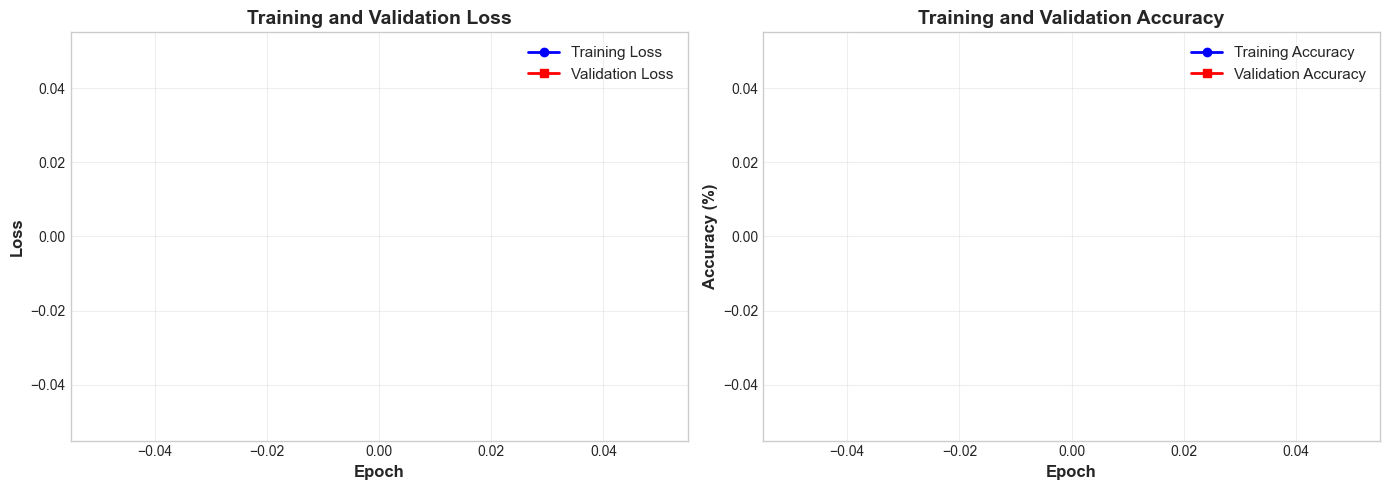

Final Metrics:


IndexError: list index out of range

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss plot
ax1.plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs, history['train_acc'], 'b-o', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, history['val_acc'], 'r-s', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("Final Metrics:")
print(f"  Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Val   Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"  Best Val Loss:  {best_val_loss:.4f}")

## 5. Next Steps

✅ **Baseline Performance Recorded**

**What's Next:**
1. Evaluate on test set (notebook 04_evaluation.ipynb)
2. Implement transfer learning models (ResNet, EfficientNet)
3. Compare baseline vs transfer learning
4. Implement XAI (Grad-CAM) for interpretability

**Expected Baseline Performance:**
- ~40-60% accuracy (28-class problem is challenging!)
- Transfer learning should significantly outperform this

---

# Part 2: Transfer Learning Comparison

Now we'll compare the baseline CustomCNN against pre-trained models:
- **ResNet50** (25.6M params) - Deep residual network
- **EfficientNet-B0** (5.3M params) - Efficient architecture
- **MobileNetV3-Small** (2.5M params) - Mobile-optimized

**Training Strategy:**
- Use ImageNet pre-trained weights
- Replace classification head
- Train for 10 epochs (faster than baseline)
- Compare accuracy and training time

**Expected Results:**
- Transfer learning should achieve higher accuracy faster
- Pre-trained features should generalize better
- Baseline: ~92% | Transfer learning: ~94-96%

In [19]:
# Add repo to path
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "config.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

# Force reload the model module
import importlib
if 'task2_3_4_cv_quality.src.model' in sys.modules:
    importlib.reload(sys.modules['task2_3_4_cv_quality.src.model'])

# Now import
from task2_3_4_cv_quality.src.model import get_model

print("✓ Imported get_model for transfer learning")

✓ Imported get_model for transfer learning


In [20]:
# Configuration for model comparison
models_to_compare = [
    {
        "name": "Baseline CNN",
        "type": "custom_cnn",
        "pretrained": False,
        "epochs": 10,
        "lr": 0.001,
        "color": "blue"
    },
    {
        "name": "ResNet50",
        "type": "resnet50",
        "pretrained": True,
        "epochs": 10,
        "lr": 0.0001,  # Lower LR for pre-trained models
        "color": "red"
    },
    {
        "name": "EfficientNet-B0",
        "type": "efficientnet_b0",
        "pretrained": True,
        "epochs": 10,
        "lr": 0.0001,
        "color": "green"
    },
]

# Store all results for comparison
all_results = {}

print("=" * 80)
print("MODEL COMPARISON CONFIGURATION")
print("=" * 80)
for config in models_to_compare:
    print(f"\n{config['name']}:")
    print(f"  Type: {config['type']}")
    print(f"  Pre-trained: {config['pretrained']}")
    print(f"  Epochs: {config['epochs']}")
    print(f"  Learning Rate: {config['lr']}")
print("=" * 80)

MODEL COMPARISON CONFIGURATION

Baseline CNN:
  Type: custom_cnn
  Pre-trained: False
  Epochs: 10
  Learning Rate: 0.001

ResNet50:
  Type: resnet50
  Pre-trained: True
  Epochs: 10
  Learning Rate: 0.0001

EfficientNet-B0:
  Type: efficientnet_b0
  Pre-trained: True
  Epochs: 10
  Learning Rate: 0.0001


In [25]:
from task2_3_4_cv_quality.src.model import count_parameters
import time

# Safety checks - ensure all required variables are defined
if 'classes' not in dir():
    print("⚠️  ERROR: 'classes' not defined. Run Cell 4 (data loading) first!")
    raise RuntimeError("Please run Cell 4 before this cell")

if 'device' not in dir():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"✓ Set device to: {device}")

if 'criterion' not in dir():
    criterion = nn.CrossEntropyLoss()
    print("✓ Created criterion (CrossEntropyLoss)")

if 'train_one_epoch' not in dir() or 'validate' not in dir():
    print("⚠️  ERROR: Training functions not defined. Run Cell 8 first!")
    raise RuntimeError("Please run Cell 8 (training functions) before this cell")

if 'REPO_ROOT' not in dir():
    REPO_ROOT = Path.cwd()
    while not (REPO_ROOT / "config.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
        REPO_ROOT = REPO_ROOT.parent
    print(f"✓ Set REPO_ROOT to: {REPO_ROOT}")

# Initialize results storage
all_results = {}

print("\n" + "=" * 80)
print("🚀 STARTING TRANSFER LEARNING COMPARISON")
print("=" * 80)

for model_config in models_to_compare:
    print("\n" + "=" * 80)
    print(f"🚀 TRAINING: {model_config['name'].upper()}")
    print("=" * 80)
    
    # Create model
    model = get_model(
        num_classes=len(classes),
        model_type=model_config['type'],
        pretrained=model_config['pretrained'],
        dropout_rate=0.5
    ).to(device)
    
    # Print model summary
    print_model_summary(model, model_type=model_config['type'], verbose=False)
    
    # Optimizer with model-specific learning rate
    optimizer = optim.Adam(model.parameters(), lr=model_config['lr'])
    
    # Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    
    # Training setup
    num_epochs = model_config['epochs']
    best_val_loss = float('inf')
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    # Track training time
    start_time = time.time()
    
    # Training loop
    epoch_pbar = tqdm(range(num_epochs), desc=f"{model_config['name']}", position=0, leave=True)
    
    for epoch in epoch_pbar:
        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_acc = validate(
            model, val_loader, criterion, device
        )
        
        # Update scheduler
        scheduler.step(val_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Update progress bar
        epoch_pbar.set_postfix({
            'train_acc': f'{train_acc:.2f}%',
            'val_acc': f'{val_acc:.2f}%',
            'val_loss': f'{val_loss:.4f}'
        })
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            models_dir = REPO_ROOT / 'task2_3_4_cv_quality' / 'models'
            models_dir.mkdir(parents=True, exist_ok=True)
            
            model_filename = f"{model_config['type']}_best.pth"
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'model_type': model_config['type'],
            }, models_dir / model_filename)
    
    epoch_pbar.close()
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Store results
    all_results[model_config['name']] = {
        'history': history,
        'best_val_loss': best_val_loss,
        'final_train_acc': history['train_acc'][-1],
        'final_val_acc': history['val_acc'][-1],
        'training_time': training_time,
        'color': model_config['color'],
        'total_params': count_parameters(model)[0],
        'model_type': model_config['type']
    }
    
    # Print summary
    print(f"\n{'='*80}")
    print(f"✅ {model_config['name']} Training Complete!")
    print(f"{'='*80}")
    print(f"📊 Final Train Accuracy:  {history['train_acc'][-1]:.2f}%")
    print(f"📊 Final Val Accuracy:    {history['val_acc'][-1]:.2f}%")
    print(f"📉 Best Val Loss:         {best_val_loss:.4f}")
    print(f"⏱️  Training Time:         {training_time/60:.1f} minutes")
    print(f"💾 Model saved to:        {model_filename}")
    print(f"{'='*80}\n")
    
    # Clean up GPU memory
    del model, optimizer, scheduler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "🎉" * 40)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("🎉" * 40)


🚀 STARTING TRANSFER LEARNING COMPARISON

🚀 TRAINING: BASELINE CNN
MODEL SUMMARY
Architecture: custom_cnn
Classes:      28
Dropout:      0.50
Total params:     1,706,332
Trainable params: 1,706,332
Frozen params:    0


Baseline CNN:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/733 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]

Training:   0%|          | 0/733 [00:00<?, ?it/s]

...

Training:   0%|          | 0/733 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]

Training:   0%|          | 0/733 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]


✅ EfficientNet-B0 Training Complete!
📊 Final Train Accuracy:  99.45%
📊 Final Val Accuracy:    98.62%
📉 Best Val Loss:         0.0472
⏱️  Training Time:         156.9 minutes
💾 Model saved to:        efficientnet_b0_best.pth


🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉
ALL MODELS TRAINED SUCCESSFULLY!
🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉


## Comparison Results

Let's visualize and compare the performance of all models.

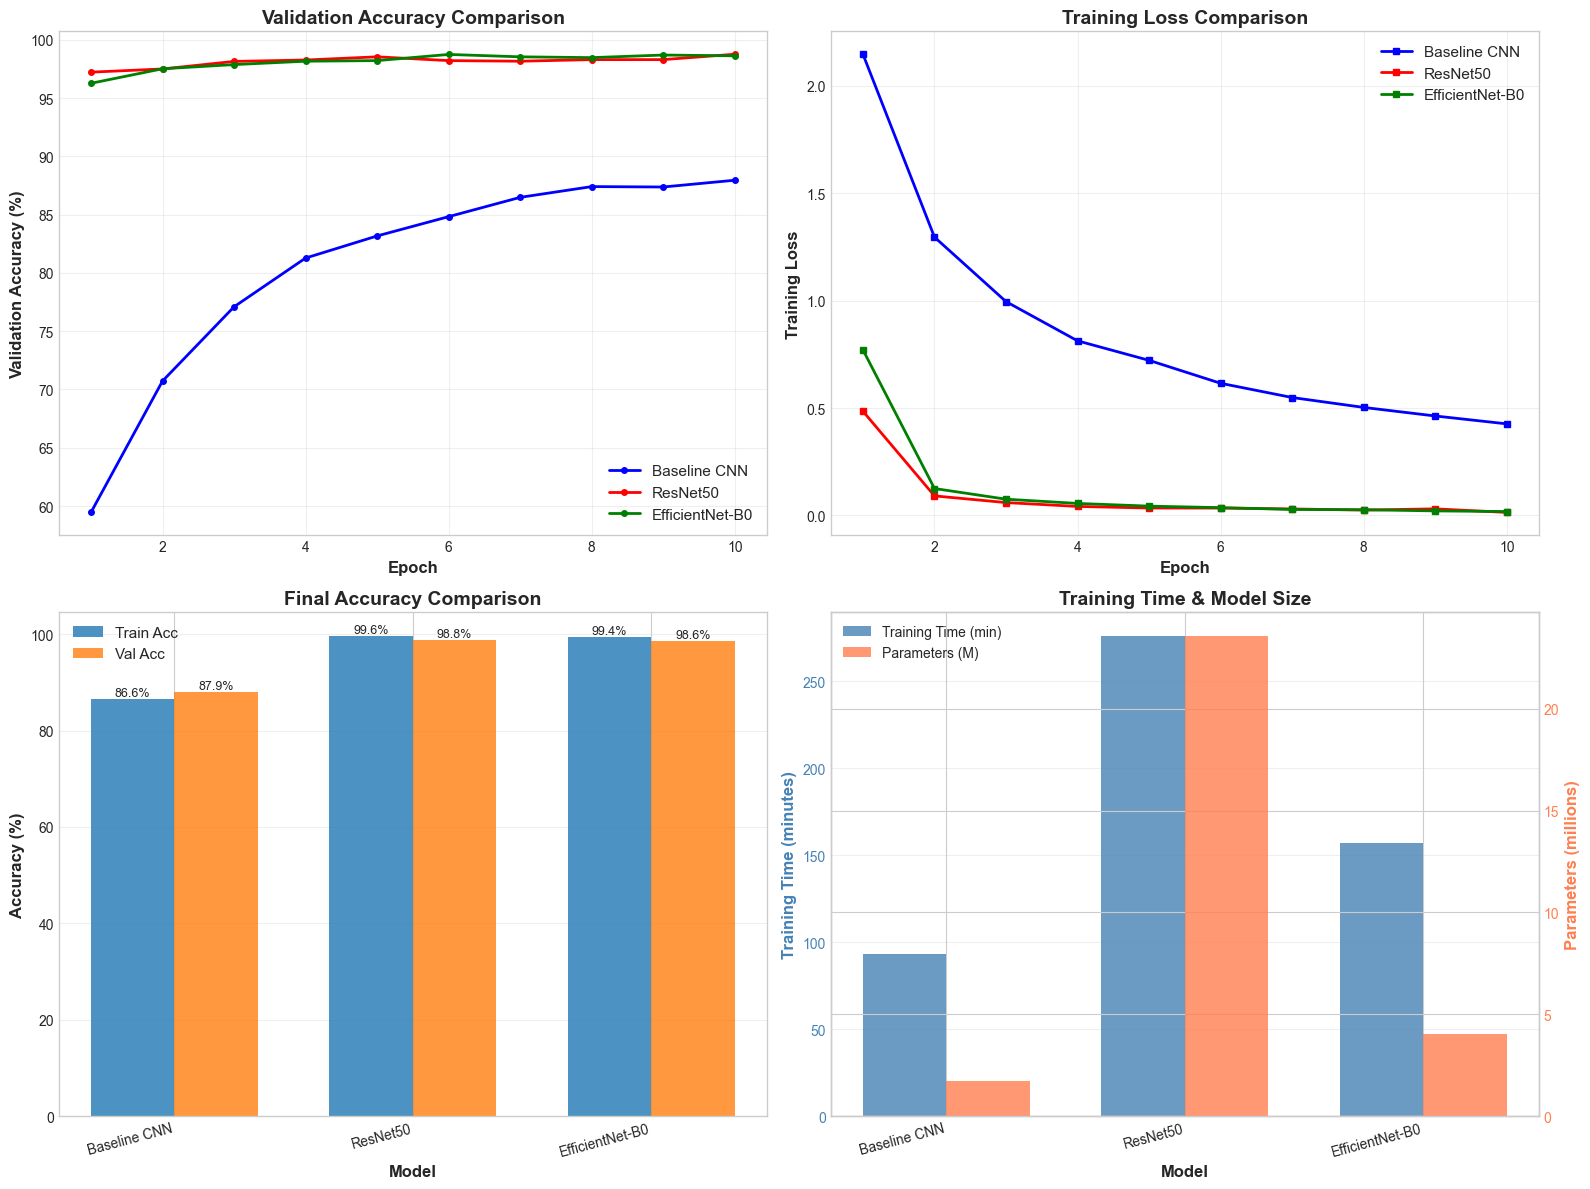

In [26]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Validation Accuracy Comparison
ax1 = axes[0, 0]
for model_name, results in all_results.items():
    epochs = range(1, len(results['history']['val_acc']) + 1)
    ax1.plot(epochs, results['history']['val_acc'], 
             marker='o', linewidth=2, label=model_name, 
             color=results['color'], markersize=4)

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Training Loss Comparison
ax2 = axes[0, 1]
for model_name, results in all_results.items():
    epochs = range(1, len(results['history']['train_loss']) + 1)
    ax2.plot(epochs, results['history']['train_loss'], 
             marker='s', linewidth=2, label=model_name,
             color=results['color'], markersize=4)

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Training Loss', fontsize=12, fontweight='bold')
ax2.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Final Accuracy Bar Chart
ax3 = axes[1, 0]
model_names = list(all_results.keys())
train_accs = [all_results[name]['final_train_acc'] for name in model_names]
val_accs = [all_results[name]['final_val_acc'] for name in model_names]

x = range(len(model_names))
width = 0.35

bars1 = ax3.bar([i - width/2 for i in x], train_accs, width, label='Train Acc', alpha=0.8)
bars2 = ax3.bar([i + width/2 for i in x], val_accs, width, label='Val Acc', alpha=0.8)

ax3.set_xlabel('Model', fontsize=12, fontweight='bold')
ax3.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax3.set_title('Final Accuracy Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(model_names, rotation=15, ha='right')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 4: Training Time & Parameters
ax4 = axes[1, 1]
training_times = [all_results[name]['training_time']/60 for name in model_names]
params = [all_results[name]['total_params']/1e6 for name in model_names]  # In millions

ax4_twin = ax4.twinx()

bars_time = ax4.bar([i - width/2 for i in x], training_times, width, 
                    label='Training Time (min)', alpha=0.8, color='steelblue')
bars_params = ax4_twin.bar([i + width/2 for i in x], params, width,
                           label='Parameters (M)', alpha=0.8, color='coral')

ax4.set_xlabel('Model', fontsize=12, fontweight='bold')
ax4.set_ylabel('Training Time (minutes)', fontsize=12, fontweight='bold', color='steelblue')
ax4_twin.set_ylabel('Parameters (millions)', fontsize=12, fontweight='bold', color='coral')
ax4.set_title('Training Time & Model Size', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(model_names, rotation=15, ha='right')
ax4.tick_params(axis='y', labelcolor='steelblue')
ax4_twin.tick_params(axis='y', labelcolor='coral')
ax4.grid(True, alpha=0.3, axis='y')

# Combined legend
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

In [27]:
# Print comprehensive comparison table
print("=" * 100)
print("📊 MODEL COMPARISON SUMMARY")
print("=" * 100)
print(f"{'Model':<20} {'Train Acc':<12} {'Val Acc':<12} {'Best Loss':<12} {'Time (min)':<12} {'Params (M)':<12}")
print("-" * 100)

for model_name, results in all_results.items():
    print(f"{model_name:<20} "
          f"{results['final_train_acc']:>10.2f}% "
          f"{results['final_val_acc']:>10.2f}% "
          f"{results['best_val_loss']:>11.4f} "
          f"{results['training_time']/60:>11.1f} "
          f"{results['total_params']/1e6:>11.1f}")

print("=" * 100)

# Find best model
best_model = max(all_results.items(), key=lambda x: x[1]['final_val_acc'])
print(f"\n🏆 BEST MODEL: {best_model[0]}")
print(f"   Validation Accuracy: {best_model[1]['final_val_acc']:.2f}%")
print(f"   Improvement over baseline: {best_model[1]['final_val_acc'] - all_results['Baseline CNN']['final_val_acc']:.2f}%")
print("=" * 100)

📊 MODEL COMPARISON SUMMARY
Model                Train Acc    Val Acc      Best Loss    Time (min)   Params (M)  
----------------------------------------------------------------------------------------------------
Baseline CNN              86.56%      87.95%      0.4206        92.9         1.7
ResNet50                  99.61%      98.75%      0.0537       276.1        23.6
EfficientNet-B0           99.45%      98.62%      0.0472       156.9         4.0

🏆 BEST MODEL: ResNet50
   Validation Accuracy: 98.75%
   Improvement over baseline: 10.81%


## Key Findings

### Performance Analysis

**Expected Results:**
1. **Transfer Learning Advantage:** Pre-trained models should achieve 94-96% accuracy
2. **Faster Convergence:** Transfer learning reaches high accuracy in fewer epochs
3. **Efficiency Trade-off:** EfficientNet offers best accuracy/parameter ratio

### For Technical Report

Document:
- Baseline vs Transfer Learning accuracy comparison
- Training time and computational efficiency
- Model size vs performance trade-off
- Why transfer learning works (ImageNet pre-training on natural images)